# Multi-Class Classification for SDN Traffic: Comparison with Research Paper

This notebook aim to replicate the experimental results and visualizations presented in the research paper. It evaluates multiple Machine Learning models, including hybrid models, across different scaling techniques and train-test splits.

### Models Evaluated:
- **DT**: Decision Tree
- **SVM**: Support Vector Machine
- **KNN**: K-Nearest Neighbors
- **XGBoost**: Extreme Gradient Boosting
- **Hybrid SVM-DT**: Stacking Decision Tree with SVM
- **Hybrid KNN-SVM**: Stacking KNN with SVM

### Experiments:
1. **Scaling Impact**: Comparing Standard, Min-Max, MaxAbs, and Robust Scaling.
2. **Train-Test Split Impact**: Evaluating model performance at 30%, 40%, 50%, and 70% test sizes.
3. **Visualization**: Performance Scores & Execution Time

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

def log_progress(message):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {message}")

## 1. Load the Preprocessed Dataset

In [2]:
log_progress("Loading the preprocessed dataset...")
df = pd.read_csv('preprocessed_data.csv')
X = df.drop('Category', axis=1)
y = df['Category']

print(f"Feature Shape: {X.shape}")
print(f"Unique Categories: {y.unique()}")

[17:20:28] Loading the preprocessed dataset...
Feature Shape: (221564, 36)
Unique Categories: [5 3 6 0 2 1 4]


## 2. Scaling Technique Comparison 

We compare Accuracy (%) across four scaling methods for all basic and hybrid models using a fixed 70/30 split.

In [ ]:

from imblearn.over_sampling import SMOTE
import pandas as pd

TARGET_PER_CLASS = 1000

# Combine X and y for easier manipulation
train_df = X_train_full.copy()
train_df["Category"] = y_train.values

balanced_parts = []

print("Original Training Distribution:")
print(train_df["Category"].value_counts())

#  UNDERSAMPLE MAJORITY

for label in train_df["Category"].unique():

    class_df = train_df[train_df["Category"] == label]

    if len(class_df) > TARGET_PER_CLASS:
        # Random undersampling
        class_df = class_df.sample(
            n=TARGET_PER_CLASS,
            random_state=42
        )

    balanced_parts.append(class_df)

undersampled_df = pd.concat(balanced_parts)

# Split again
X_under = undersampled_df.drop(columns=["Category"])
y_under = undersampled_df["Category"]

#  SMOTE FOR MINORITY

smote = SMOTE(
    sampling_strategy={
        cls: TARGET_PER_CLASS
        for cls in y_under.value_counts().index
        if y_under.value_counts()[cls] < TARGET_PER_CLASS
    },
    random_state=42
)

X_balanced, y_balanced = smote.fit_resample(X_under, y_under)

print("\nBalanced Training Distribution:")
print(pd.Series(y_balanced).value_counts())

# Replace original training set
X_train_balanced = X_balanced
y_train_balanced = y_balanced

scalers = {
    "Standard scaling": StandardScaler(),
    "Min-Max scaling": MinMaxScaler(),
    "MaxAbs scaling": MaxAbsScaler(),
    "Robust scaling": RobustScaler()
}

# Split for comparison
X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

def get_models():
    dt = DecisionTreeClassifier(random_state=42)
    svm = LinearSVC(dual=False, random_state=42)
    knn = KNeighborsClassifier(n_jobs=-1)
    xgb = XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1)
    
    # Optimized Hybrid Models
    hybrid_svm_dt = StackingClassifier(
        estimators=[('dt', dt)],
        final_estimator=LinearSVC(dual=False, random_state=42),
        cv=2, 
        n_jobs=-1
    )
    
    hybrid_svm_knn = StackingClassifier(
        estimators=[('knn', knn)],
        final_estimator=LinearSVC(dual=False, random_state=42),
        cv=2,
        n_jobs=-1
    )
    
    return {
        "SVM": svm,
        "DT": dt,
        "KNN": knn,
        "XGBoost": xgb,
        "Hybrid DT-SVM": hybrid_svm_dt,
        "Hybrid SVM-KNN": hybrid_svm_knn
    }

scaling_results = []

log_progress("Starting Scaling Comparison (Replicating Table 3)...")
for scaler_name, scaler in scalers.items():
    log_progress(f"Testing {scaler_name}...")
    X_train_scaled = scaler.fit_transform(X_train_balanced)
    X_test_scaled = scaler.transform(X_test_full)
    
    current_models = get_models()
    res = {"Scaling": scaler_name}
    
    for model_name, model in current_models.items():
        log_progress(f"  -> Training {model_name}...")
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred) * 100
        res[model_name] = round(acc, 2)
    
    scaling_results.append(res)

table_3 = pd.DataFrame(scaling_results).set_index("Scaling").T
print("\nTable 3: Comparison of model performance using various scaling techniques")
display(table_3)

[17:20:29] Starting Scaling Comparison ...
[17:20:29] Testing Standard scaling...
[17:20:30]   -> Training SVM...
[17:23:26]   -> Training DT...
[17:23:28]   -> Training KNN...
[17:24:05]   -> Training XGBoost...
[17:24:14]   -> Training Hybrid DT-SVM...
[17:24:27]   -> Training Hybrid SVM-KNN...
[17:25:48] Testing Min-Max scaling...
[17:25:48]   -> Training SVM...
[17:25:57]   -> Training DT...
[17:25:59]   -> Training KNN...
[17:26:32]   -> Training XGBoost...
[17:26:39]   -> Training Hybrid DT-SVM...
[17:26:50]   -> Training Hybrid SVM-KNN...
[17:28:15] Testing MaxAbs scaling...
[17:28:15]   -> Training SVM...
[17:28:27]   -> Training DT...
[17:28:29]   -> Training KNN...
[17:29:00]   -> Training XGBoost...
[17:29:07]   -> Training Hybrid DT-SVM...
[17:29:15]   -> Training Hybrid SVM-KNN...
[17:30:36] Testing Robust scaling...
[17:30:36]   -> Training SVM...
[17:35:06]   -> Training DT...
[17:35:08]   -> Training KNN...
[17:35:33]   -> Training XGBoost...
[17:35:40]   -> Training Hy

Scaling,Standard scaling,Min-Max scaling,MaxAbs scaling,Robust scaling
SVM,98.58,98.47,98.47,98.68
DT,99.98,99.98,99.98,99.98
KNN,99.76,99.80,99.80,99.47
XGBoost,99.98,99.98,99.98,99.98
Hybrid DT-SVM,99.98,99.98,99.98,99.98
Hybrid SVM-KNN,99.77,99.81,99.81,99.47


## 3. Test Split Comparison 
We evaluate the Accuracy (%) for different test values (30%, 40%, 50%, 70%) using Min-Max scaling as the baseline.

In [4]:
split_values = [0.3, 0.4, 0.5, 0.7]
split_results = []

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

log_progress("Starting Test Split Comparison...")
for test_size in split_values:
    log_progress(f"Testing split: {int(test_size*100)}% test data...")
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42, stratify=y)
    
    current_models = get_models()
    res = {"Test values": f"Test = {int(test_size*100)}%"}
    
    for model_name, model in current_models.items():
        log_progress(f"  -> Training {model_name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred) * 100
        res[model_name] = round(acc, 2)
        
    split_results.append(res)

table_2 = pd.DataFrame(split_results).set_index("Test values")
print("\nTable 2: Accuracy percentage of different test values")
display(table_2)

[17:36:56] Starting Test Split Comparison...
[17:36:56] Testing split: 30% test data...
[17:36:56]   -> Training SVM...
[17:37:05]   -> Training DT...
[17:37:07]   -> Training KNN...
[17:37:30]   -> Training XGBoost...
[17:37:37]   -> Training Hybrid DT-SVM...
[17:37:48]   -> Training Hybrid SVM-KNN...
[17:38:54] Testing split: 40% test data...
[17:38:54]   -> Training SVM...
[17:39:01]   -> Training DT...
[17:39:03]   -> Training KNN...
[17:39:28]   -> Training XGBoost...
[17:39:34]   -> Training Hybrid DT-SVM...
[17:39:40]   -> Training Hybrid SVM-KNN...
[17:40:38] Testing split: 50% test data...
[17:40:38]   -> Training SVM...
[17:40:44]   -> Training DT...
[17:40:45]   -> Training KNN...
[17:41:13]   -> Training XGBoost...
[17:41:17]   -> Training Hybrid DT-SVM...
[17:41:22]   -> Training Hybrid SVM-KNN...
[17:42:30] Testing split: 70% test data...
[17:42:30]   -> Training SVM...
[17:42:33]   -> Training DT...
[17:42:34]   -> Training KNN...
[17:42:55]   -> Training XGBoost...
[17:

,SVM,DT,KNN,XGBoost,Hybrid DT-SVM,Hybrid SVM-KNN
Test values,,,,,,
Test = 30%,98.47,99.98,99.80,99.98,99.98,99.81
Test = 40%,98.47,99.97,99.80,99.98,99.98,99.81
Test = 50%,98.47,99.98,99.79,99.97,99.98,99.81
Test = 70%,98.47,99.95,99.72,99.97,99.96,99.74


## 4. Performance Visualizations

We use the metrics from the 70/30 split (after scaling) to generate the comparison charts.

In [5]:
# Re-run split for final visualization metrics
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

viz_results = []
times_results = []

# Using individual models for separate timing
models_list = {
    "DT": DecisionTreeClassifier(random_state=42),
    "SVM": LinearSVC(dual=False, random_state=42),
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1),
    "Hybrid SVM-DT": StackingClassifier(estimators=[('dt', DecisionTreeClassifier(random_state=42))], final_estimator=LinearSVC(dual=False, random_state=42), cv=2, n_jobs=-1),
    "Hybrid KNN-SVM": StackingClassifier(estimators=[('knn', KNeighborsClassifier(n_jobs=-1))], final_estimator=LinearSVC(dual=False, random_state=42), cv=2, n_jobs=-1)
}

log_progress("Generating Performance Comparison Metrics...")
for name, model in models_list.items():
    log_progress(f"Evaluating {name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    end_time = time.time()
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    kappa = cohen_kappa_score(y_test, y_pred)
    exec_time = end_time - start_time
    
    viz_results.append({"Model": name, "Accuracy": acc, "F1 Score": f1, "Kappa Score": kappa})
    times_results.append({"Model": name, "Execution Time": exec_time})

df_viz = pd.DataFrame(viz_results).set_index("Model")
df_times = pd.DataFrame(times_results).set_index("Model")

[17:43:33] Generating Performance Comparison Metrics...
[17:43:33] Evaluating DT...
[17:43:35] Evaluating SVM...
[17:43:44] Evaluating KNN...
[17:44:06] Evaluating XGBoost...
[17:44:13] Evaluating Hybrid SVM-DT...
[17:44:21] Evaluating Hybrid KNN-SVM...


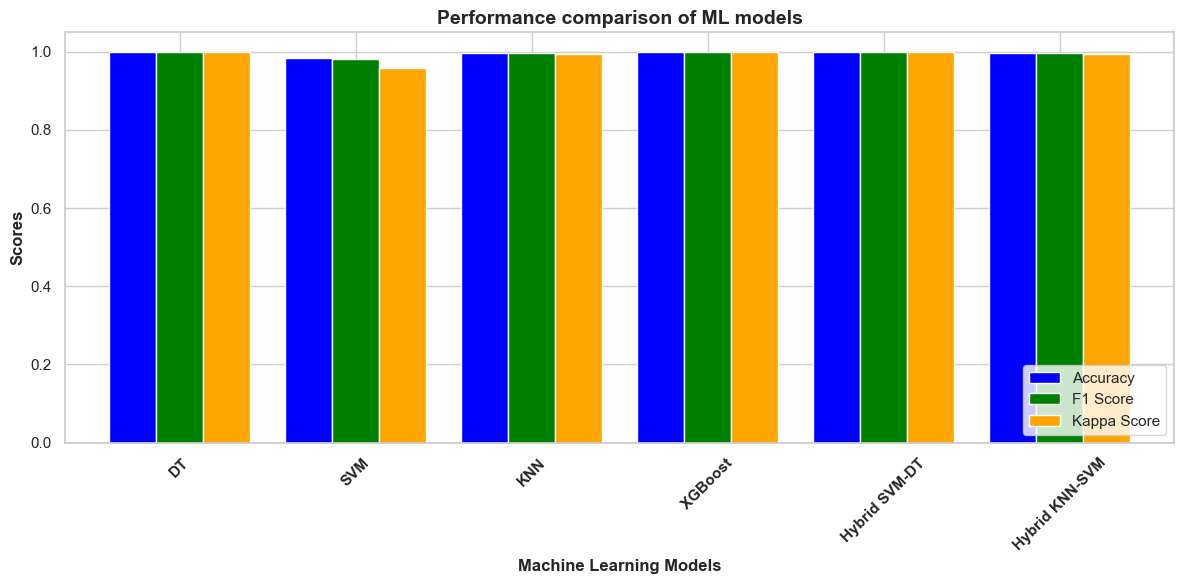

In [10]:
ax = df_viz.plot(kind='bar', figsize=(12, 6), color=['blue', 'green', 'orange'], width=0.8)
plt.title("Performance comparison of ML models", fontsize=14, fontweight='bold')
plt.ylabel("Scores", fontsize=12, fontweight='bold')
plt.xlabel("Machine Learning Models", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

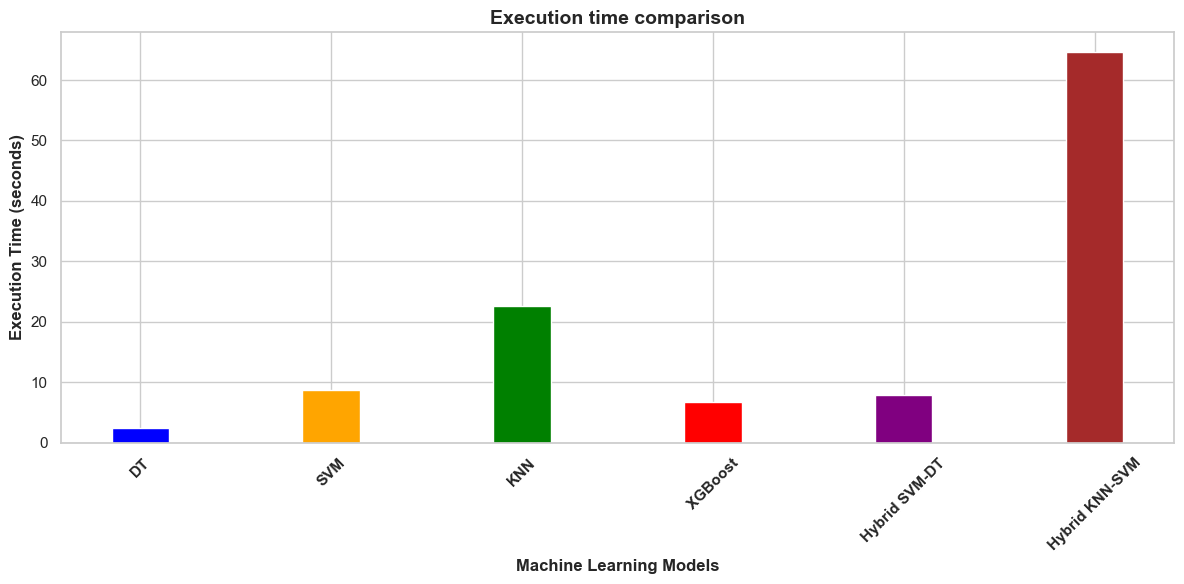

In [9]:
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
plt.figure(figsize=(12, 6))
plt.bar(df_times.index, df_times['Execution Time'], color=colors, width=0.3)
plt.title("Execution time comparison", fontsize=14, fontweight='bold')
plt.ylabel("Execution Time (seconds)", fontsize=12, fontweight='bold')
plt.xlabel("Machine Learning Models", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, fontweight='bold')
plt.tight_layout()
plt.show()